#### Bibliotecas

In [31]:
# Bibliotecas
import numpy as np
import sys
import warnings
sys.path.append(r'C:\Users\Miyamura\Desktop\GIT_MESTRADO\ppgsi_comparable_mdp_risk\app')

# Problem Definition
from ppgsi_configuration_region.residuals.error_metrics import ErrorMetrics
from ppgsi_configuration_region.methods.value_function_factory import ValueFunctionFactory
from ppgsi_configuration_region.viz.mss_plots import MSSPlots

# Including Warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MSS - Multiple Sequential States Problem
---

Let $n$ be the number of states $\left\{ s_0, s_1, ..., s_n \right\}$, and each state has an action $a_i$ with a probability $p_i$ of transitioning to state $s_{i+1}$ and a probability $(1-p_i)$ of returning to the initial state $s_0$.

## Define Parâmetros
---

In [32]:
# ==================
# Definições Inicias
# ------------------
results = {}

# Custo por Ação
c = 1

# Probabilidade por Ação
p = 0.5
p0 = (1 - p)

# Quantidade de Estados
n = 3

# Numero de simulações
num_simulations = int(1e5)
np.random.seed = 42

# Parametros das metricas

# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
vl_lambda = 0.01
_epsilon = int(1e-5)
_threshold = 1e4
_alpha = 0.99

EM_EXP = ErrorMetrics(_epsilon)

# Parâmetros -------------------
# -- Visualization
# ------------------------------
range_n = np.arange(1, 4, 1)
range_p = np.arange(0.1, 0.9, 0.05)

## Risk-Neutral
---
Value function formulation for MSS:

$$  $$

Analytical value function formulation for MSS:

$$ V^{n}(s_0) = \frac{c \sum_{i=0}^{n} p^{i}}{p^{n}} $$

In [33]:
rn_method = 'risk_neutral'
rn_obj = ValueFunctionFactory().get_calculator(method=rn_method)
results[rn_method] = {}

# 1.1. Simulacao
results[rn_method]['mss_value_function'], costs = rn_obj.mss_value_function(c, p, n, num_simulations)

# 1.2. Via Formula Analítica
results[rn_method]['mss_analytical_value_function'] = rn_obj.mss_analytical_value_function(c, p, n)

# Print results
print('1. Risk Neutral')
print('1.1. Valor via Simulacao:', results[rn_method]['mss_value_function'])
print('1.2. Valor via Formula Analitica:', results[rn_method]['mss_analytical_value_function'])

1. Risk Neutral
1.1. Valor via Simulacao: 13.98653
1.2. Valor via Formula Analitica: 14.0


## Exponential Utility Method
---

$$
    V^{\pi}(s_0) = e^{-\lambda c(s, \pi(s))} \sum_{s' \in \mathcal{S}} T(s, \pi(s), s') V^{\pi}(s')
$$

In [34]:
# Define metodos ---------------
# -- Exponential Utility Method.
# ------------------------------

# Criando objeto para Exponential Utility Function
exp_method = 'exponential_utility_function'
exp_obj = ValueFunctionFactory().get_calculator(method=exp_method)
results[exp_method] = {}

# MSS > Calcula Funcao Valor
results[exp_method]['mss_value_function'] = exp_obj.mss_value_function(n, p, c, vl_lambda, _threshold, _epsilon)
print('Algoritmo:', results[exp_method]['mss_value_function'])

# MSS > Calcula Formula analítica (se houver)
results[exp_method]['mss_analytical_value_function'] = exp_obj.mss_analytical_value_function(n, p, c, vl_lambda)
print('Analítico:', results[exp_method]['mss_analytical_value_function'])

Algoritmo: {0: 1.1591919355450424, 1: 1.136123630594449, 2: 1.090446087632029, 'sG': 1.0}
Analítico: {0: 1.1591919355450429}



              Calculando valores para os seguintes parâmetros:
                p: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85] | 
                c: 1 | 
                lambda: 0.01 |
              


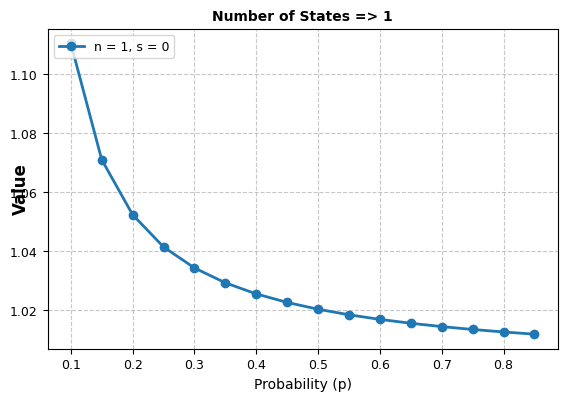

In [35]:
# OSMA > Calcula configuration region para cada probabilidade (p)
results[exp_method]['osma_value_function_range_probability'] = exp_obj.osma_value_function_range_probability(range_p, c, vl_lambda)
MSSPlots().subplots_for_number_of_states(results[exp_method]['osma_value_function_range_probability'], sharey=False)

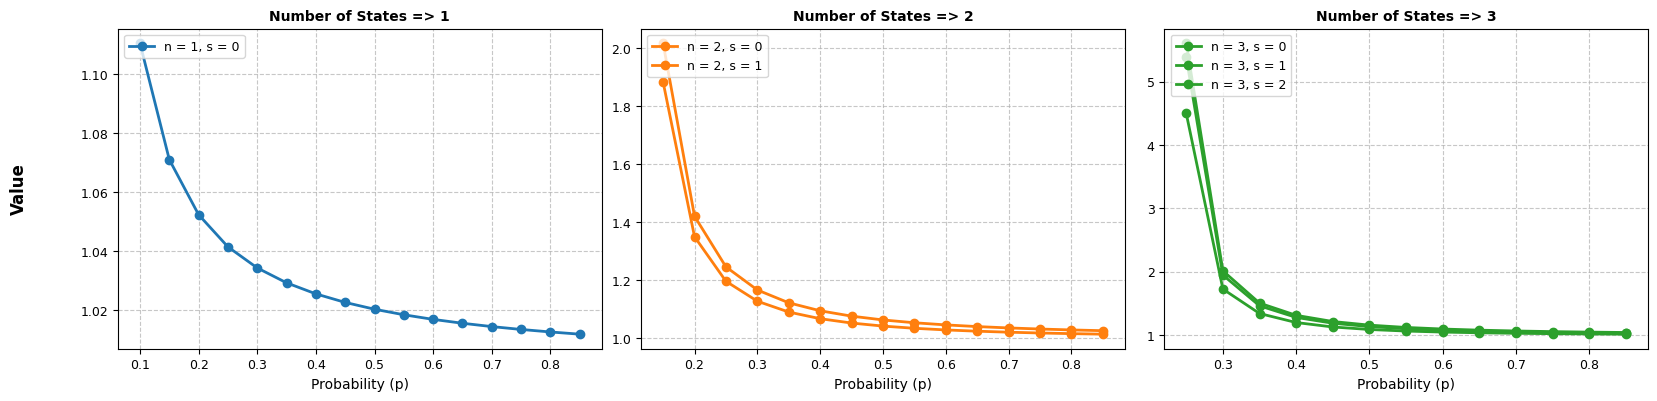

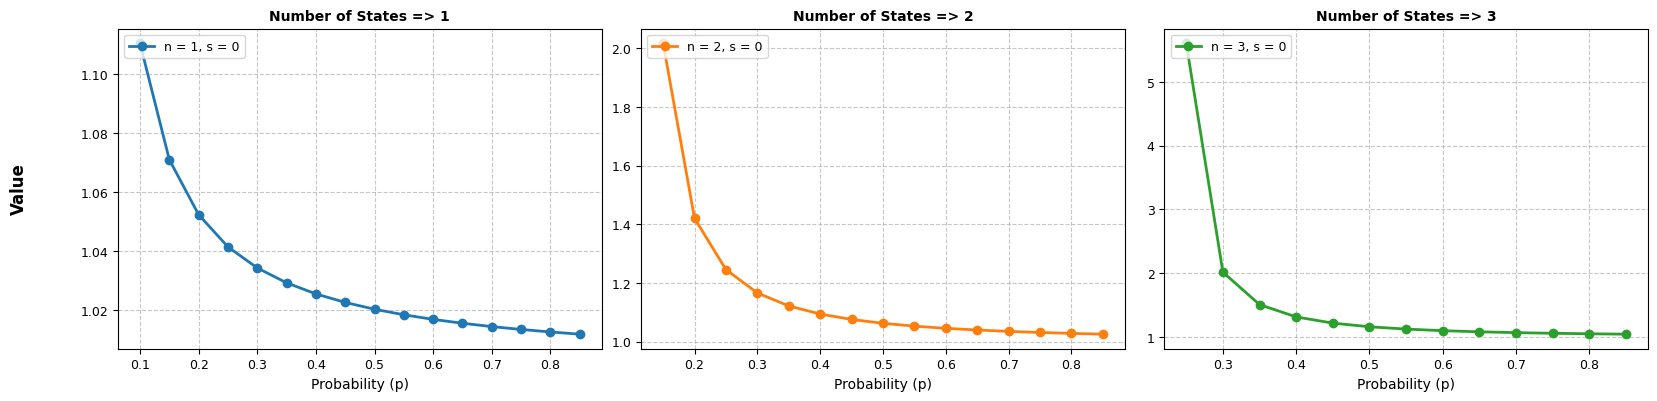

In [36]:
# MSS > Calcula configuration region para cada numero de estado (n) e cada probabilidade (p)
# ==========================================================================================
results[exp_method]['mss_value_function_range_probability'] = exp_obj.mss_value_function_range_probability(range_n, range_p, c, vl_lambda, _threshold, _epsilon)
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_value_function_range_probability'], sharey=False, plot_only_first_state=False)
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_value_function_range_probability'], sharey=False, plot_only_first_state=True)

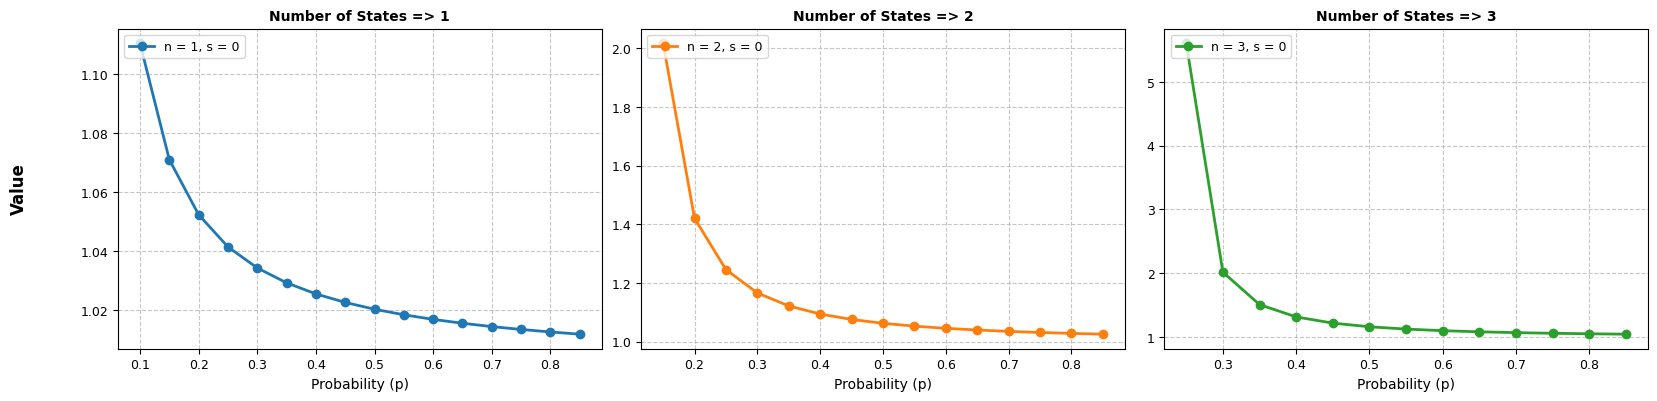

In [37]:
# MSS > Calcula funcao valor analitica para um intervalo de probabilidade (p)
# ===========================================================================
results[exp_method]['mss_analytical_value_function_range_probability'] = exp_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, vl_lambda)
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_analytical_value_function_range_probability'], sharey=False, plot_only_first_state=True)

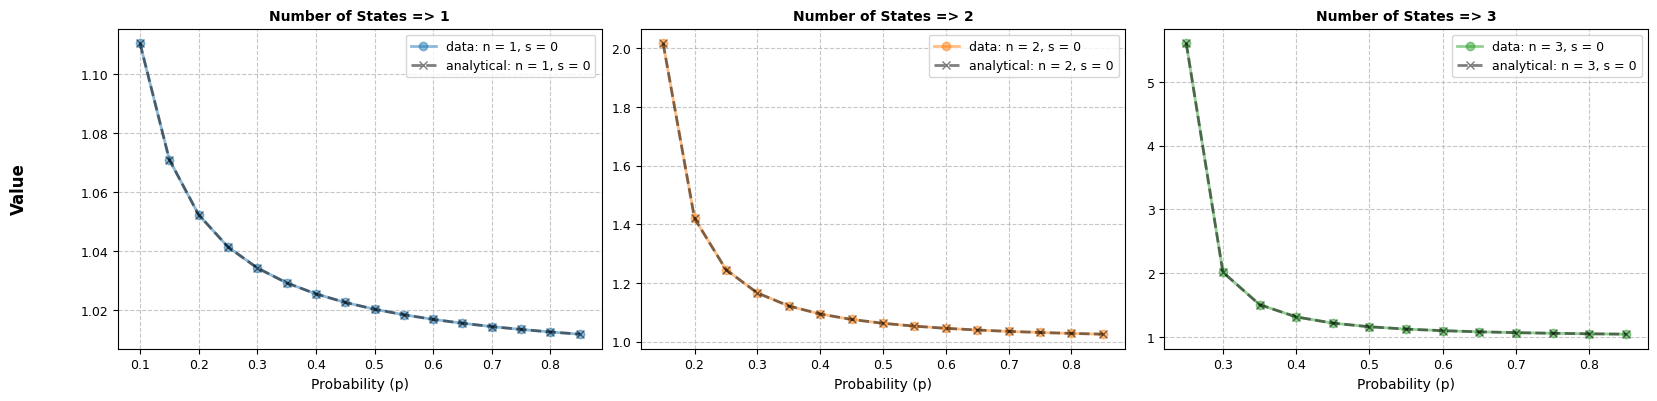

In [38]:
# Comparativo da funcao valor analitica com a simulada
# ====================================================
MSSPlots().compare_data_and_analytical(
    data=results[exp_method]['mss_value_function_range_probability'], 
    data_analytical=results[exp_method]['mss_analytical_value_function_range_probability'], 
    sharey=False, 
    plot_only_first_state=True
)

### Calculating Lambda-Extreme
---

Lambda Extreme: {0: 0.08376931712393898}


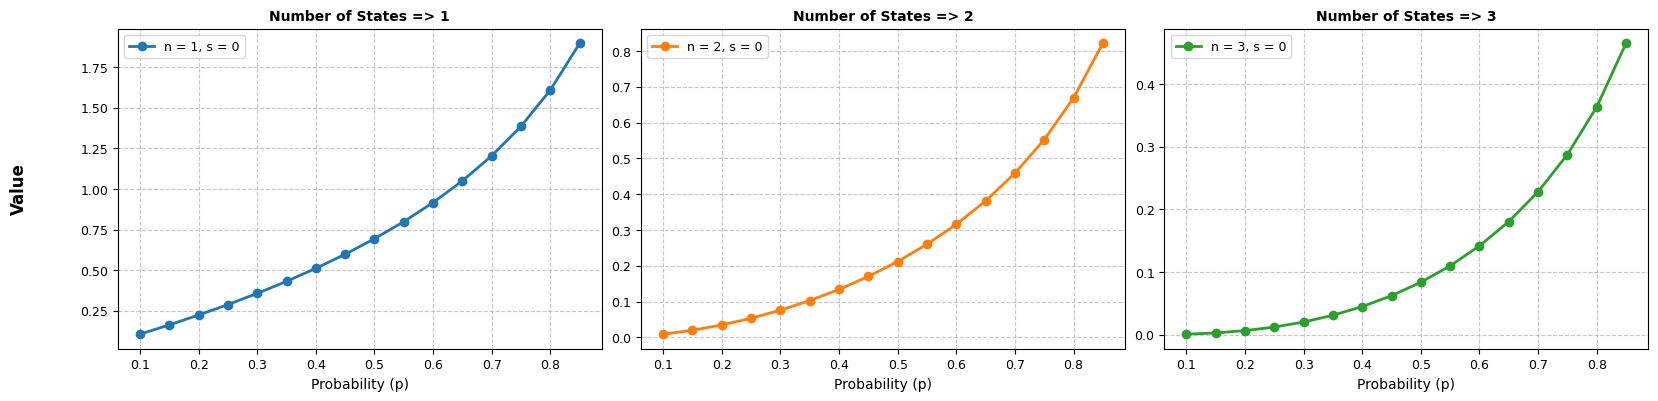

In [39]:
# Calcual Lambda Extreme
# ----------------------
from ppgsi_configuration_region.methods.exponential_utility_function import LambdaExtreme
_le = LambdaExtreme()

_lambda_extreme_epsilon = 0.00001
_lambda_extreme_beta = 0.0001

# MSS > Calcula lambda extreme para um determinado n e um p
results[exp_method]['solver_lambda_extreme_mss'] = _le.solver_lambda_extreme_mss(n=3, p=0.5, c=c)
print('Lambda Extreme:', results[exp_method]['solver_lambda_extreme_mss'])

# MSS > Calcula lambda extreme para cada numero de estado (n) e cada probabilidade (p)
results[exp_method]['find_numerical_lambda_extreme_range_probability'] = _le.find_numerical_lambda_extreme_range_probability(n=range_n, p=range_p, c=c)
MSSPlots().subplots_for_number_of_states(results[exp_method]['find_numerical_lambda_extreme_range_probability'], sharey=False)

### Configuration Region for EUM (Exponential Utility Function) - Equivalent Cost

--- 

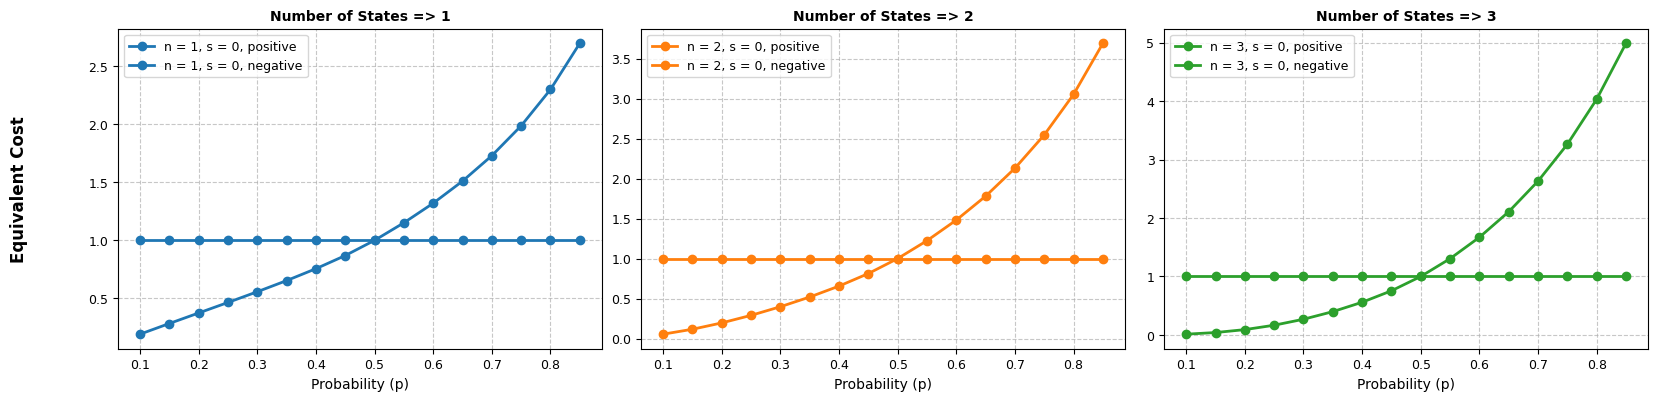

In [40]:
# Regiao de configuracao alterando o valor do custo
# =================================================
results[exp_method]['run_configuration_region'] = exp_obj.run_configuration_region(n=range_n, p=range_p, cr=c, pr=p, analytical=True, _threshold=_threshold, _epsilon=_epsilon)
MSSPlots().plot_configuration_region(results[exp_method]['run_configuration_region'], sharey=False, y_label='Equivalent Cost')

### Configuration Region for EUM (Exponential Utility Function) - Equivalent Number of States

--- 

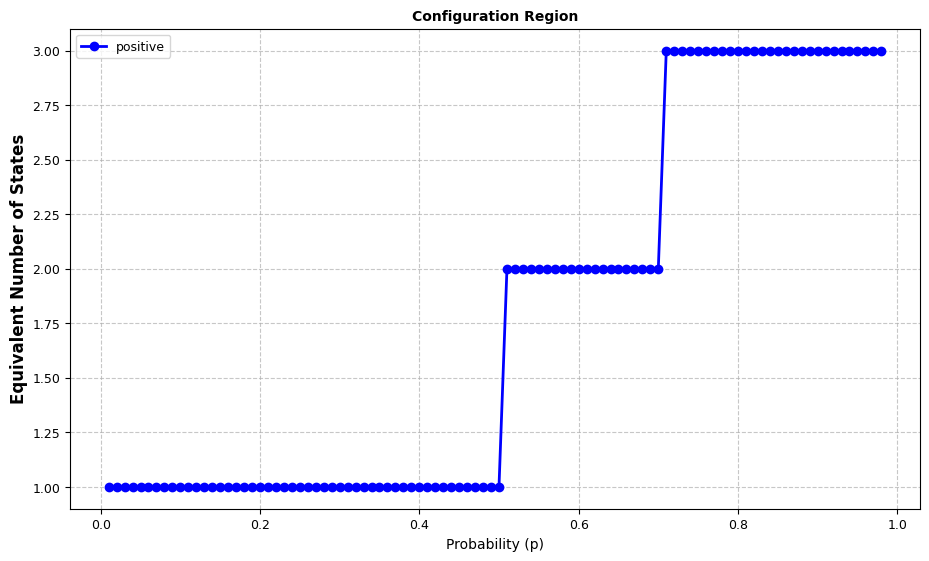

In [41]:
# Um unico grafico com probabilidade no eixo x e numero de estados (n) no eixo y
# - Mantendo um custo fixo
# ==============================================================================
results[exp_method]['run_solver_for_number_states'] = exp_obj.run_solver_for_number_states(
    n=range_n, 
    p=np.arange(0.01, 0.99, 0.01), 
    c=c,
    nr=2, 
    pr=0.5, 
    vl_lambda=0.1,
    _threshold=_threshold, 
    _epsilon=_epsilon, 
)

MSSPlots().plot_configuration_region_arrays(results[exp_method]['run_solver_for_number_states'], x_values=np.arange(0.01, 0.99, 0.01), sharey=False, y_label='Equivalent Number of States')

In [42]:
analytical = True
nr = 2
pr = 0.5

if analytical:
    # Positive Values
    positive_values = exp_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, None)
    
    # Negative Values
    negative_values = exp_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, -1e5)
else:
    # Positive Values
    positive_values = exp_obj.mss_value_function_range_probability(range_n, range_p, c, None, _threshold, _epsilon)
    
    # Negative Values
    negative_values = exp_obj.mss_value_function_range_probability(range_n, range_p, c, -1e5, _threshold, _epsilon)

positive_values_for_each_probability = {}
negative_values_for_each_probability = {}

for num_states in positive_values.keys():
    for prob in positive_values[num_states].keys():
        if prob not in positive_values_for_each_probability.keys(): positive_values_for_each_probability[prob] = np.array([])
        positive_values_for_each_probability[prob] = np.append(positive_values_for_each_probability[prob], positive_values[num_states][prob][0])
        
for num_states in negative_values.keys():
    for prob in negative_values[num_states].keys():
        if prob not in negative_values_for_each_probability.keys(): negative_values_for_each_probability[prob] = np.array([])
        negative_values_for_each_probability[prob] = np.append(negative_values_for_each_probability[prob], negative_values[num_states][prob][0])
        
positive_reference_value = positive_values[nr][pr][0]
negative_reference_value = negative_values[nr][pr][0]

pos = np.array([])
for prob in range_p:
    prob = prob.round(2)
    try:
        print(positive_values_for_each_probability[prob][positive_values_for_each_probability[prob] - positive_reference_value < 0])
        max_number = np.argmax(positive_values_for_each_probability[prob][positive_values_for_each_probability[prob] - positive_reference_value < 0]) + 1
    except:
        max_number = 1
    pos = np.append(pos, max_number)
    
neg = np.array([])
for prob in range_p:
    prob = prob.round(2)
    try:
        max_number = np.argmax(negative_values_for_each_probability[prob][negative_values_for_each_probability[prob] - negative_reference_value < 0]) + 1
    except:
        max_number = 1
    neg = np.append(neg, max_number)
    
res = {}
res['positive'] = pos
res['negative'] = neg

res

[111.05556481   9.31733553]
[176.38236765  20.65011466   2.91089966]
[249.87502083  36.56212624   6.6320725 ]
[57.48136782 12.54287865]
[84.10950145 21.16790651]
[117.4782753   33.14479674]
[159.05494292  49.30433574]
[210.9190055   70.78184532]
[99.18778036]
[136.88874602]
[187.50065114]
[256.81284628]
[]
[]
[]
[]


{'positive': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'negative': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}

## Piecewise-linear Transformation
---

[Risk-Sensitive Piecewise-Linear Policy Iteration for Stochastic Shortest Path Markov Decision Processes] \
Formally, an infinity-horizon, an infinite-horizon RS-MDP is defined by a tuple $\langle M, k \rangle$, where $-1 < k < 1$ is the risk factor and $M$ is an infinite-horizon MDP. The approach proposed uses the piecewise-linear transformation function $\chi^{(k)}(x)$ which depends on the input $x$ (temporal difference) be it positive or not and on the risk factor $k$. This function is defined by:

$$
    \chi^{(k)}(x) =
        \begin{cases}
        (1 - k)x, & \text{if } x < 0, \\
        (1 + k)x, & \text{otherwise.}
        \end{cases}
$$

Given a stationary policy $\pi$, the corresponding value function $V_{k}^{\pi}(s)$ can be obtained by solving the following system of equations for all $s \in \mathcal{S}$:

$$
    \sum_{s' \in S} P(s' \mid s, \pi(s)) \chi^{(k)} \left( C(s, \pi(s), s') + \gamma V_k^{\pi}(s') - V_k^{\pi}(s) \right) = 0
$$

---

**Theorem 3.** If $k \in (-1, 1)$, $0 \leq \gamma < 1$ and $0 < \alpha \leq (1 + \mid k \mid)^{-1}$, the operator $O^{\pi}_{\alpha, k}[V]$ defined next is a contraction mapping:

$$
    O^{\pi}_{\alpha, k}[V](s) = V(s) + \alpha \sum_{s' \in \mathcal{S}} P(s' \mid s, \pi(s)) \chi^{(k)}(x)(C(s, \pi(s), s') + \gamma V(s') - V(s))
$$

i.e., for all functions $V_1$ and $V_2$, we have:
$
\lvert \mathcal{O}^{\pi}_{\alpha,k}[V_1] - \mathcal{O}^{\pi}_{\alpha,k}[V_2] \rvert 
\leq \rho \lvert V_1 - V_2 \rvert,
$
for some $\rho = (1 - \alpha (1 - \lvert k \rvert)(1 - \gamma)) \in (0, 1) < 1$.
The scalar $\alpha$ is a positive step-size.

In [43]:
# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
k = 0.3
alpha = 1 / (1 + abs(k))
gamma = 1
_epsilon = 1e-4
_threshold = int(1e6)

pr = 0.5
nr = 2
cr = 1

In [44]:
# Criando objeto para Exponential Utility Function
plt_method = 'piecewise_linear_transformation'
plt_obj = ValueFunctionFactory().get_calculator(method=plt_method)
results[plt_method] = {}

# MSS > Value function
results[plt_method]['mss_value_function'] = plt_obj.mss_value_function(2, p, c, k, alpha, gamma, _threshold, _epsilon, _verbose=False)
print('Value Function:', results[plt_method]['mss_value_function'])

Value Function: {0: 11.019225734308634, 1: 8.16241338356239, 2: 0.0}


In [45]:
# MSS > Analytical value function
plt_obj.mss_analytical_value_function(2, p, c, k)

{0: 11.020408163265309}

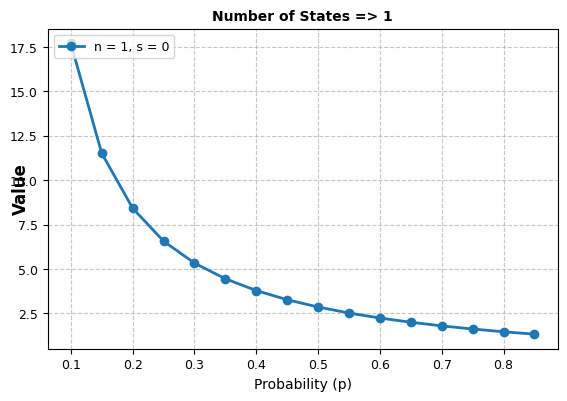

In [46]:
# OSMA > Value function
results[plt_method]['osma_value_function_range_probability'] = plt_obj.osma_value_function_range_probability(range_p, c, k)
MSSPlots().subplots_for_number_of_states(results[plt_method]['osma_value_function_range_probability'], sharey=False)

In [47]:
# MSS > Value function
results[plt_method]['mss_value_function_range_probability'] = plt_obj.mss_value_function_range_probability(range_n, range_p, c, k, alpha, gamma, _threshold, _epsilon, _verbose=False)

In [48]:
# MSS > Analytical value function
results[plt_method]['mss_analytical_value_function_range_probability'] = plt_obj.mss_analytical_value_function_range_probability(range_n, range_p, c, k)

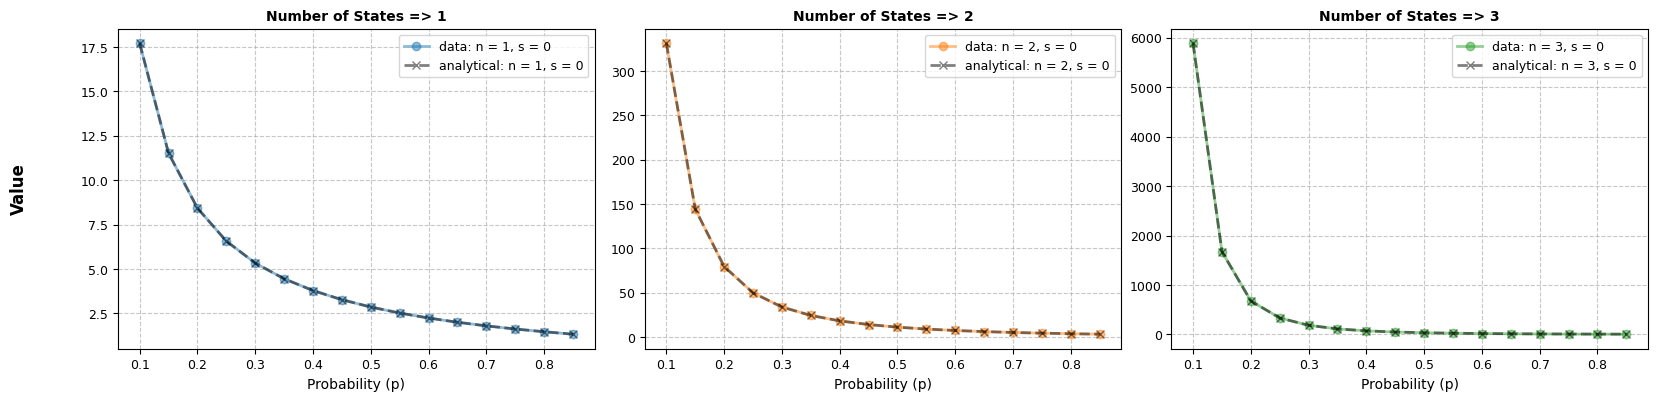

In [49]:
MSSPlots().compare_data_and_analytical(
    data=results[plt_method]['mss_value_function_range_probability'], 
    data_analytical=results[plt_method]['mss_analytical_value_function_range_probability'], 
    sharey=False, 
    plot_only_first_state=True
)

### Configuration Region for PLT (Piecewise-Linear Transformation)

--- 

In [50]:
results[plt_method]['run_configuration_region'] = \
    plt_obj.run_configuration_region(
        n=range_n,
        p=range_p,
        cr=cr,
        pr=pr,
        alpha=alpha,
        gamma=gamma,
        analytical=True,
        _threshold=_threshold,
        _epsilon=_epsilon,
    )

 number states: 100%|██████████| 3/3 [00:00<00:00, 146.31it/s]


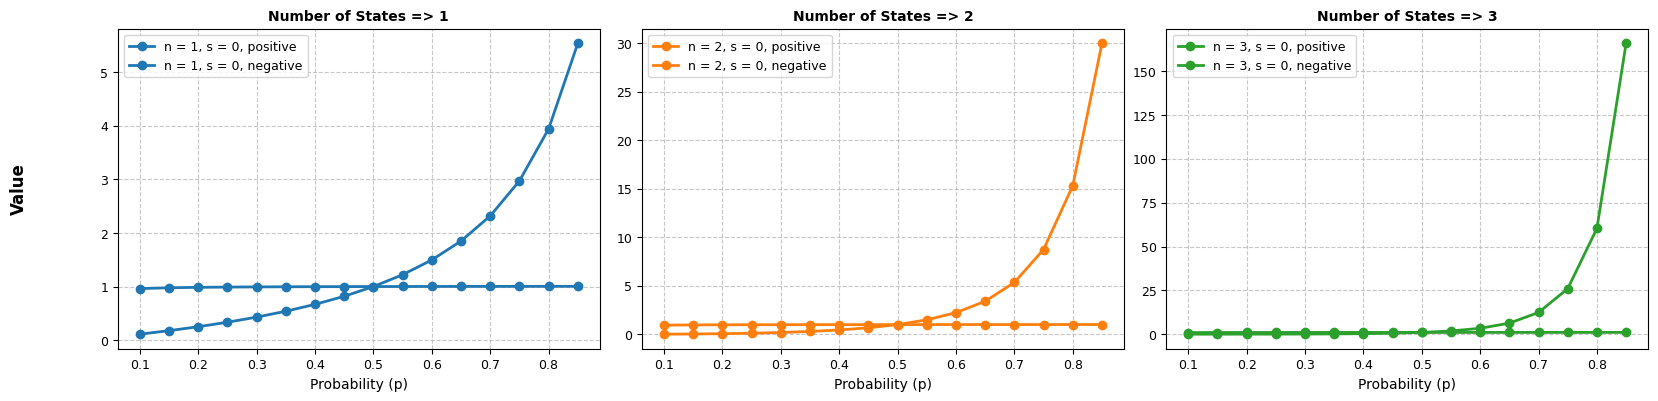

In [51]:
MSSPlots().plot_configuration_region(results[plt_method]['run_configuration_region'], sharey=False)

# Comparing - Exponential Utility Function vs Piecewise-Linear Transformation (EXP vs PLT)

---

In [52]:
# def transform_keys_to_string(d):
#     if isinstance(d, dict):
#         return {str(k): transform_keys_to_string(v) for k, v in d.items()}
#     return d

# results[plt_method]['run_configuration_region'] = transform_keys_to_string(results[plt_method]['run_configuration_region'])

# import json
# with open('plt_run_configuration_region.json', 'w') as f:
#     json.dump(results[plt_method]['run_configuration_region'], f)

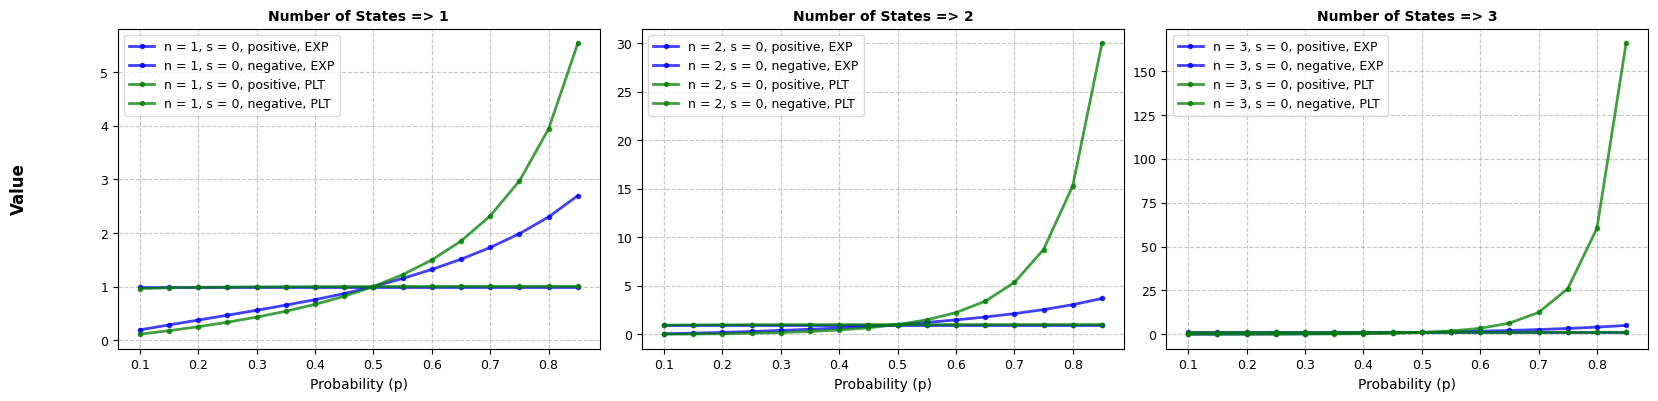

In [53]:
MSSPlots().plot_compare_configuration_region(results[exp_method]['run_configuration_region'], results[plt_method]['run_configuration_region'], method1='EXP', method2='PLT', sharey=False)

### Equivalent Number of States

7.160493827160493 {0.1: array([  12.,  156., 1884.]), 0.15: array([  7.92592593,  70.74622771, 568.65528629]), 0.2: array([  5.88888889,  40.56790123, 244.78875171]), 0.25: array([  4.66666667,  26.44444444, 128.07407407]), 0.3: array([ 3.85185185, 18.68861454, 75.83762638]), 0.35: array([ 3.26984127, 13.9617032 , 48.92239459]), 0.4: array([ 2.83333333, 10.86111111, 33.60648148]), 0.45: array([ 2.49382716,  8.71300107, 24.22254587]), 0.5: array([ 2.22222222,  7.16049383, 18.13443073]), 0.55: array([ 2.,  6., 14.]), 0.6: array([ 1.81481481,  5.10836763, 11.08555606]), 0.65: array([1.65811966, 4.40748046, 8.96624965]), 0.7: array([1.52380952, 3.84580499, 7.38408379]), 0.75: array([1.40740741, 3.38820302, 6.17598943]), 0.8: array([1.30555556, 3.01003086, 5.23531807]), 0.85: array([1.21568627, 2.69357939, 4.49023377])}


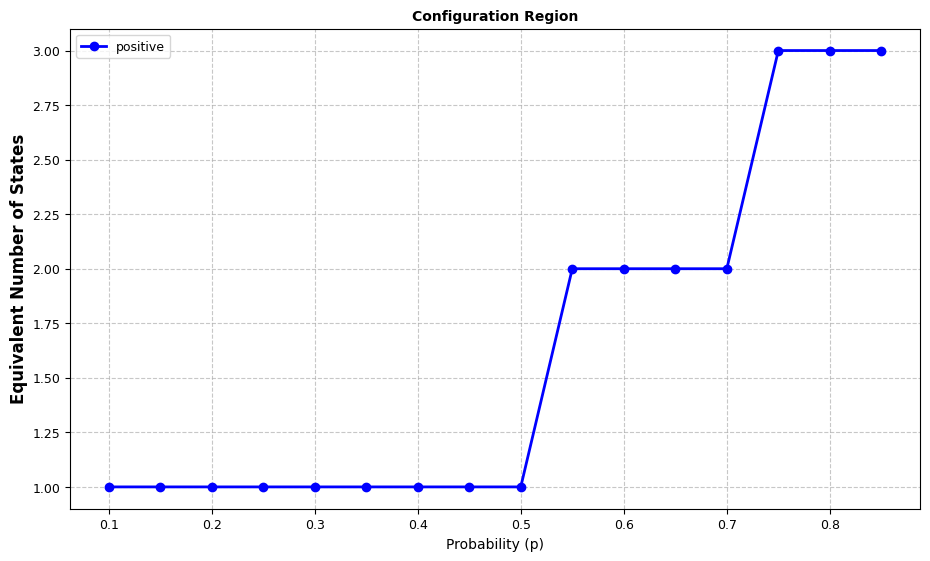

In [54]:
results[plt_method]['run_solver_for_number_states'] = plt_obj.run_solver_for_number_states(
    n=range_n,
    p=range_p,
    c=c,
    pr=pr,
    nr=nr,
    k=0.1,
    alpha=1 / (1 + abs(k)),
    gamma=1,
    analytical=True,
    _threshold=_threshold,
    _epsilon=_epsilon,
    _quiet=True,
)

MSSPlots().plot_configuration_region_arrays(results[plt_method]['run_solver_for_number_states'], x_values=range_p, sharey=False, y_label='Equivalent Number of States')

In [55]:
results[plt_method]['run_configuration_region_number_states'] = plt_obj.run_configuration_region_number_states(
    n=range_n,
    p=range_p,
    c=c,
    pr=pr,
    nr=nr,
    alpha=None,
    gamma=1,
    analytical=True,
    _threshold=_threshold,
    _epsilon=_epsilon,
    _quiet=True,
)

In [56]:
results[plt_method]['run_configuration_region_number_states']

{'positive': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2.]),
 'negative': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2.])}

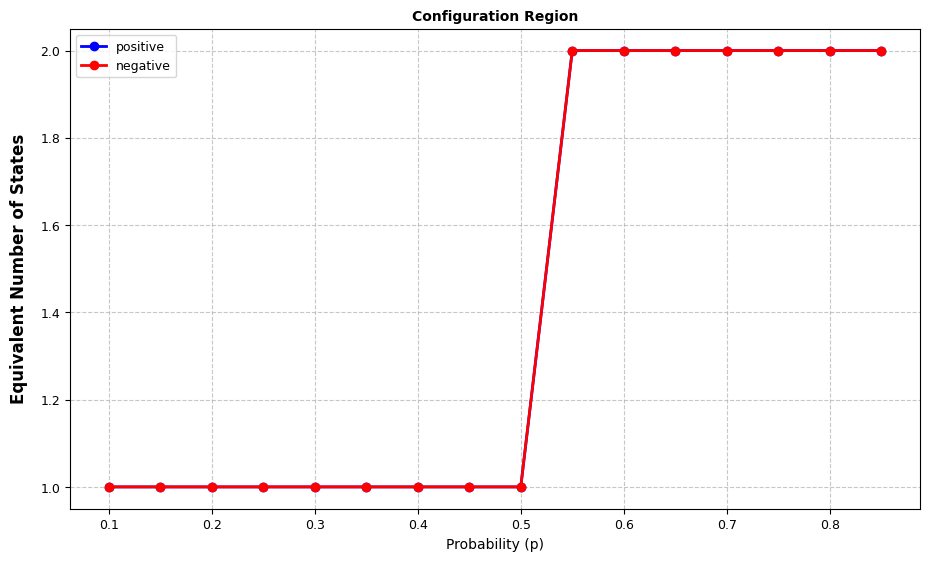

In [57]:
MSSPlots().plot_configuration_region_arrays(results[plt_method]['run_configuration_region_number_states'], x_values=range_p, sharey=False, y_label='Equivalent Number of States')

## Stochastic Dominance
---

Stochastic dominance is a method of comparing different probability distributions. It is used in decision theory and economics to rank investments, policies, or other choices under uncertainty. There are different orders of stochastic dominance, with the first and second orders being the most common.

1. **First-order Stochastic Dominance (FSD)**: A distribution $ F $ first-order stochastically dominates another distribution $ G $ if for any value $ x $, the cumulative distribution function (CDF) of $ F $ is always less than or equal to the CDF of $ G $, and there is at least one $ x $ for which the inequality is strict. Mathematically, $ F $ dominates $ G $ if:
    $$
    F(x) \leq G(x) \quad \text{for all } x \quad \text{and} \quad F(x) < G(x) \quad \text{for some } x
    $$

2. **Second-order Stochastic Dominance (SSD)**: A distribution $ F $ second-order stochastically dominates another distribution $ G $ if the area under the CDF of $ F $ up to any point $ x $ is less than or equal to the area under the CDF of $ G $ up to that point, and there is at least one $ x $ for which the inequality is strict. Mathematically, $ F $ dominates $ G $ if:
    $$
    \int_{-\infty}^{x} F(t) \, dt \leq \int_{-\infty}^{x} G(t) \, dt \quad \text{for all } x \quad \text{and} \quad \int_{-\infty}^{x} F(t) \, dt < \int_{-\infty}^{x} G(t) \, dt \quad \text{for some } x
    $$

The **Cumulative Distribution Function (CDF)** of a random variable $ X $ is a function that maps a value $ x $ to the probability that $ X $ will take a value less than or equal to $ x $. It is defined as:
$$
F(x) = P(X \leq x)
$$
The CDF is a non-decreasing, right-continuous function that ranges from 0 to 1. It provides a complete description of the probability distribution of a random variable.

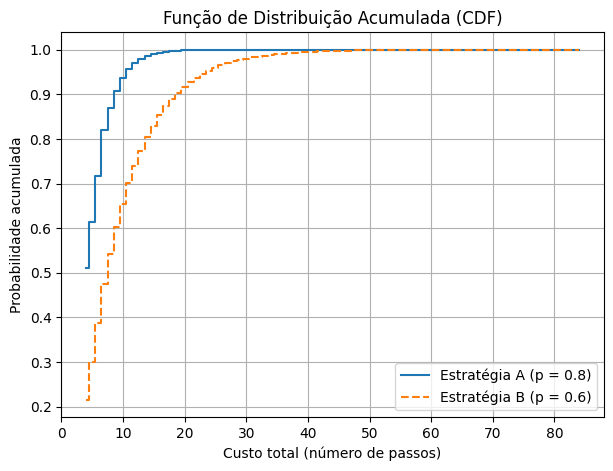

(array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
        55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84]),
 array([0.51042, 0.6141 , 0.71693, 0.81904, 0.86916, 0.90834, 0.93771,
        0.95654, 0.96993, 0.97901, 0.9853 , 0.98953, 0.99279, 0.99508,
        0.99657, 0.99766, 0.99847, 0.99901, 0.99931, 0.99949, 0.99962,
        0.99974, 0.99982, 0.99987, 0.99993, 0.99993, 0.99995, 0.99997,
        0.99998, 0.99998, 0.99998, 0.99998, 0.99999, 0.99999, 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.  

In [58]:
import matplotlib.pyplot as plt

# Parâmetros do problema
n_states = 3  # Número de estados intermediários
trials = 100000  # Número de simulações

# Probabilidades para as duas estratégias
p_A = 0.8  # Avançar na Estratégia A
p_B = 0.6  # Avançar na Estratégia B

# Função para simular o custo total
def simulate_cost(p_a, n_states, trials):
    costs = []
    for _ in range(trials):
        steps = 0
        current_state = 0
        while current_state < n_states:
            steps += 1
            if np.random.rand() <= p_a:
                current_state += 1  # Avança para o próximo estado
            else:
                current_state = 0  # Volta ao estado inicial
        costs.append(steps + 1)  # +1 pelo passo final até s_G
    return np.array(costs)

# Simulações
costs_A = simulate_cost(p_A, n_states, trials)
costs_B = simulate_cost(p_B, n_states, trials)

# Funções de distribuição acumulada (CDF)
cost_range = np.arange(min(costs_A.min(), costs_B.min()), max(costs_A.max(), costs_B.max()) + 1)
cdf_A = np.array([np.mean(costs_A <= c) for c in cost_range])
cdf_B = np.array([np.mean(costs_B <= c) for c in cost_range])

# Plot
plt.figure(figsize=(7, 5))
plt.step(cost_range, cdf_A, label='Estratégia A (p = 0.8)', where='mid')
plt.step(cost_range, cdf_B, label='Estratégia B (p = 0.6)', where='mid', linestyle='--')
plt.xlabel('Custo total (número de passos)')
plt.ylabel('Probabilidade acumulada')
plt.title('Função de Distribuição Acumulada (CDF)')
plt.legend()
plt.grid(True)
plt.show()

# Integrais das CDFs para a SSD
integral_A = np.cumsum(cdf_A)
integral_B = np.cumsum(cdf_B)

(cost_range, cdf_A, cdf_B, integral_A, integral_B)

## Value at Risk

## Conditional Value at Risk

## Mean-variance